# Apache Spark: SparkContext vs SparkSession
## 1. Introduction to Spark Entry Points
### What is an Entry Point?

An entry point in Apache Spark is the gateway to distributed computing capabilities. It serves as the connection between your application and the Spark cluster, managing resources and coordinating data processing operations.

### Evolution Timeline

- **Pre-Spark 2.0 (2016)**: SparkContext was the primary entry point
- **Spark 2.0+**: SparkSession introduced as unified entry point
- **Current Best Practice**: SparkSession is preferred for most applications

### Key Concepts

- **SparkContext**: Original, low-level entry point for RDD operations
- **SparkSession**: Modern, unified entry point supporting DataFrames, SQL, and streaming
- **Backward Compatibility**: SparkSession includes SparkContext internally

---

## 2. SparkContext Deep Dive
### Overview

SparkContext is the foundational entry point in Spark, designed for low-level RDD (Resilient Distributed Dataset) operations. It provides fine-grained control over distributed data processing.

### Key Responsibilities

1. **Cluster Connection**: Links application to cluster managers (Standalone, YARN, Kubernetes)
2. **Resource Management**: Allocates executors and manages memory/CPU
3. **RDD Operations**: Creates and manages RDDs with transformations and actions
4. **Configuration**: Sets application properties and cluster settings

### Creating SparkContext in PySpark

```python
from pyspark import SparkContext, SparkConf

# Method 1: Using SparkConf
conf = SparkConf()
conf.setAppName("MySparkApp")
conf.setMaster("local[*]")  # Use all available cores locally
conf.set("spark.executor.memory", "4g")
conf.set("spark.driver.memory", "2g")

sc = SparkContext(conf=conf)

# Method 2: Direct instantiation
sc = SparkContext(
    appName="MySparkApp",
    master="local[*]"
)
```

### Important SparkConf Parameters

|Parameter|Description|Example|
|---|---|---|
|`setAppName(name)`|Names the application|`"WordCount"`|
|`setMaster(url)`|Specifies cluster manager|`"local[*]"`, `"yarn"`, `"spark://host:port"`|
|`set(key, value)`|Custom properties|`"spark.executor.memory", "4g"`|

### Key SparkContext Methods

```python
# Reading data
rdd = sc.textFile("path/to/file.txt", minPartitions=4)
rdd = sc.parallelize([1, 2, 3, 4, 5], numSlices=2)

# Configuration and control
sc.setLogLevel("WARN")  # Set logging level
config = sc.getConf()   # Get current configuration
sc.stop()               # Shutdown context
```

### Complete Word Count Example with SparkContext

```python
from pyspark import SparkContext, SparkConf

# Setup configuration
conf = SparkConf().setAppName("WordCount").setMaster("local[*]")
sc = SparkContext(conf=conf)

try:
    # Read input file
    lines = sc.textFile("input.txt")
    
    # Process data using RDD transformations
    words = lines.flatMap(lambda line: line.split(" "))
    word_pairs = words.map(lambda word: (word.lower().strip(), 1))
    word_counts = word_pairs.reduceByKey(lambda a, b: a + b)
    
    # Collect results
    results = word_counts.collect()
    
    # Display results
    for word, count in results:
        print(f"{word}: {count}")
    
    # Save results
    word_counts.saveAsTextFile("output_sparkcontext")
    
finally:
    sc.stop()
```

### RDD Transformation Methods

|Method|Description|Example|
|---|---|---|
|`map(func)`|Transform each element|`rdd.map(lambda x: x * 2)`|
|`flatMap(func)`|Transform and flatten|`rdd.flatMap(lambda x: x.split())`|
|`filter(func)`|Filter elements|`rdd.filter(lambda x: x > 0)`|
|`reduceByKey(func)`|Reduce values by key|`rdd.reduceByKey(lambda a, b: a + b)`|

---

## 3. SparkSession Deep Dive

### Overview

SparkSession is the unified entry point introduced in Spark 2.0, consolidating multiple contexts (SparkContext, SQLContext, StreamingContext) into a single API. It's the modern standard for Spark applications.

### Key Responsibilities

1. **Unified Access**: Combines RDD, DataFrame, and SQL functionalities
2. **Cluster Connection**: Connects to cluster like SparkContext
3. **Resource Management**: Manages executors and configurations
4. **DataFrame/SQL Operations**: Supports structured data with optimizations
5. **Streaming & ML Support**: Enables real-time processing and machine learning

### Creating SparkSession in PySpark

```python
from pyspark.sql import SparkSession

# Basic creation
spark = SparkSession.builder \
    .appName("MySparkApp") \
    .master("local[*]") \
    .getOrCreate()

# Advanced configuration
spark = SparkSession.builder \
    .appName("AdvancedApp") \
    .master("local[*]") \
    .config("spark.executor.memory", "4g") \
    .config("spark.driver.memory", "2g") \
    .config("spark.sql.shuffle.partitions", "200") \
    .enableHiveSupport() \
    .getOrCreate()
```

### SparkSession Builder Parameters

|Method|Description|Example|
|---|---|---|
|`appName(name)`|Set application name|`.appName("MyApp")`|
|`master(url)`|Set cluster manager|`.master("local[*]")`|
|`config(key, value)`|Set configuration|`.config("spark.executor.memory", "4g")`|
|`getOrCreate()`|Get existing or create new session|Returns SparkSession instance|

### Key SparkSession Methods

```python
# Data reading
df = spark.read.text("path/to/file.txt")
df = spark.read.csv("path/to/file.csv", header=True, inferSchema=True)
df = spark.read.json("path/to/file.json")

# SQL operations
spark.sql("SELECT * FROM table_name")

# DataFrame creation
df = spark.createDataFrame(data, schema=None)

# Access underlying SparkContext
sc = spark.sparkContext

# Configuration
spark.conf.set("spark.sql.shuffle.partitions", "100")

# Shutdown
spark.stop()
```

### Complete Word Count Example with SparkSession

```python
from pyspark.sql import SparkSession
from pyspark.sql.functions import explode, split, lower, trim

# Create SparkSession
spark = SparkSession.builder \
    .appName("WordCount") \
    .master("local[*]") \
    .getOrCreate()

try:
    # Read input file as DataFrame
    df = spark.read.text("input.txt")
    
    # Process using DataFrame operations
    words_df = df.select(
        explode(split(df.value, " ")).alias("word")
    ).select(
        lower(trim("word")).alias("word")
    ).filter(
        "word != ''"
    )
    
    # Count words
    word_counts = words_df.groupBy("word").count().orderBy("count", ascending=False)
    
    # Show results
    word_counts.show(20)
    
    # Save results
    word_counts.write.mode("overwrite").csv("output_sparksession")
    
finally:
    spark.stop()
```

### Alternative SQL Approach

```python
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("WordCountSQL").master("local[*]").getOrCreate()

try:
    # Read and create temporary view
    df = spark.read.text("input.txt")
    df.createOrReplaceTempView("lines")
    
    # Use SQL for word count
    result = spark.sql("""
        SELECT word, COUNT(*) as count
        FROM (
            SELECT explode(split(value, ' ')) as word
            FROM lines
        ) words
        WHERE word != ''
        GROUP BY word
        ORDER BY count DESC
    """)
    
    result.show()
    
finally:
    spark.stop()
```

---

## 4. Comprehensive Comparison
### 1. Purpose and Scope

|Aspect|SparkContext|SparkSession|
|---|---|---|
|**Primary Use**|RDD-based processing|Unified API (RDD, DataFrame, SQL)|
|**Data Focus**|Unstructured data|Structured and semi-structured data|
|**API Level**|Low-level operations|High-level abstractions|
|**Additional Contexts**|Requires SQLContext, etc.|All-in-one solution|

### 2. API Complexity

**SparkContext Example:**

```python
# Verbose RDD operations
rdd = sc.textFile("file.txt")
result = rdd.flatMap(lambda x: x.split()) \
           .map(lambda x: (x, 1)) \
           .reduceByKey(lambda a, b: a + b)
```

**SparkSession Example:**

```python
# Concise DataFrame operations
df = spark.read.text("file.txt")
result = df.select(explode(split("value", " ")).alias("word")) \
          .groupBy("word").count()
```

### 3. Performance Optimizations

|Feature|SparkContext|SparkSession|
|---|---|---|
|**Query Optimization**|Manual optimization required|Automatic via Catalyst Optimizer|
|**Memory Management**|Basic RDD caching|Advanced Tungsten engine|
|**Join Optimization**|Manual implementation|Automatic broadcast joins|
|**Predicate Pushdown**|Not available|Automatic optimization|

> Predicate Pushdown = pushing the filtering logic( like `WHERE` clauses) as close as to the data source so that less data is read into spark.


### 4. Feature Support Matrix

| Feature                  | SparkContext              | SparkSession              |
| ------------------------ | ------------------------- | ------------------------- |
| **RDD Operations**       | Native                    | Via sparkContext        |
| **DataFrame API**        | `NA`, Requires SQLContext | Native                  |
| **SQL Queries**          | `NA`, Requires SQLContext | Native                  |
| **Structured Streaming** | `NA`                      | Native                  |
| **Machine Learning**     | MLlib (RDD-based)         | ML (DataFrame-based)    |
| **Graph Processing**     | GraphX                    | GraphX via sparkContext |

---


In [1]:
# In Python
from pyspark.sql import SparkSession
from pyspark.sql.functions import avg
# Create a DataFrame using SparkSession
spark = (SparkSession
.builder
.appName("AuthorsAges")
.getOrCreate())
# Create a DataFrame
data_df = spark.createDataFrame([("Brooke", 20), ("Denny", 31), ("Jules", 30),("TD", 35), ("Brooke", 25)], ["name", "age"])
# Group the same names together, aggregate their ages, and compute an average
avg_df = data_df.groupBy("name").agg(avg("age"))
# Show the results of the final execution
avg_df.show()

+------+--------+
|  name|avg(age)|
+------+--------+
|Brooke|    22.5|
| Denny|    31.0|
| Jules|    30.0|
|    TD|    35.0|
+------+--------+



In [6]:
spark.catalog

# The DataFrame API
Inspired by pandas DataFrames in structure, format, and a few specific operations, Spark DataFrames are like distributed in-memory tables with named columns and schemas, where each column has a specific data type: integer, string, array, map, real, date, timestamp, etc. To a human’s eye, a Spark DataFrame is like a table.






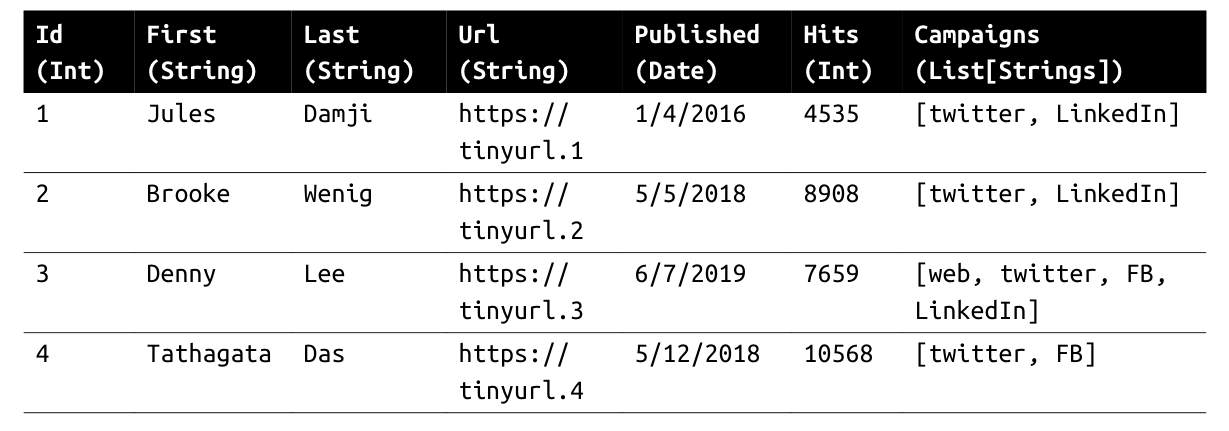

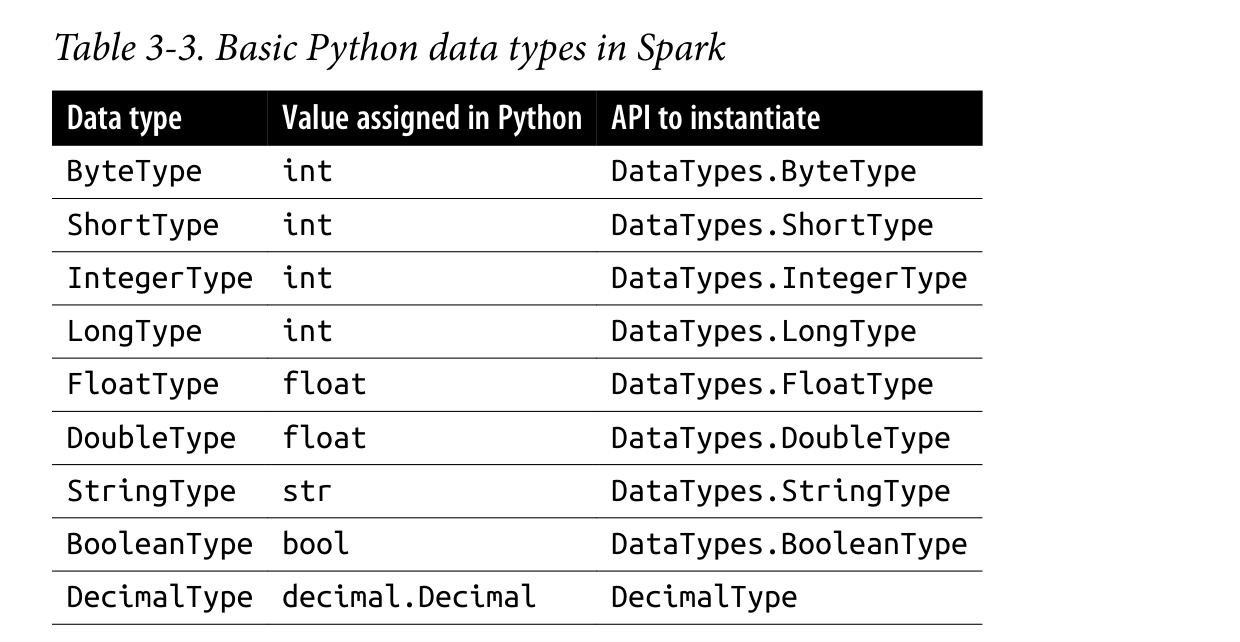

## Two ways to define a schema
Programmatically, and the other is to employ a
Data Definition Language (DDL) string, which is
much simpler and easier to read.

To define a schema programmatically for a DataFrame with three named columns,
author, title, and pages, you can use the Spark DataFrame API. For example:

In [7]:
# 1.
from pyspark.sql.types import *
schema = StructType([StructField("author", StringType(), False),
StructField("title", StringType(), False),
StructField("pages", IntegerType(), False)])

In [8]:
# 2. Defining the same schema using DDL is much simpler:
schema = "author STRING, title STRING, pages INT"


In [9]:
# We can use both..its upto you whichever you like

In [11]:
# In Python
from pyspark.sql import SparkSession
# Define schema for our data using DDL
schema = "`Id` INT, `First` STRING, `Last` STRING, `Url` STRING,`Published` STRING, `Hits` INT, `Campaigns` ARRAY<STRING>"
# Create our static data
data = [[1, "Jules", "Damji", "https://tinyurl.1", "1/4/2016", 4535, ["twitter","LinkedIn"]],
[2, "Brooke","Wenig", "https://tinyurl.2", "5/5/2018", 8908, ["twitter",
"LinkedIn"]],
[3, "Denny", "Lee", "https://tinyurl.3", "6/7/2019", 7659, ["web",
"twitter", "FB", "LinkedIn"]],
[4, "Tathagata", "Das", "https://tinyurl.4", "5/12/2018", 10568,
["twitter", "FB"]],
[5, "Matei","Zaharia", "https://tinyurl.5", "5/14/2014", 40578, ["web",
"twitter", "FB", "LinkedIn"]],
[6, "Reynold", "Xin", "https://tinyurl.6", "3/2/2015", 25568,
["twitter", "LinkedIn"]]
]
# Main program
if __name__ == "__main__":
  # Create a SparkSession
  spark = (SparkSession
  .builder
  .appName("Example-3_6")
  .getOrCreate())
  # Create a DataFrame using the schema defined above
  blogs_df = spark.createDataFrame(data, schema)
  # Show the DataFrame; it should reflect our table above
  blogs_df.show()
  # Print the schema used by Spark to process the DataFrame
  blogs_df.printSchema()

+---+---------+-------+-----------------+---------+-----+--------------------+
| Id|    First|   Last|              Url|Published| Hits|           Campaigns|
+---+---------+-------+-----------------+---------+-----+--------------------+
|  1|    Jules|  Damji|https://tinyurl.1| 1/4/2016| 4535| [twitter, LinkedIn]|
|  2|   Brooke|  Wenig|https://tinyurl.2| 5/5/2018| 8908| [twitter, LinkedIn]|
|  3|    Denny|    Lee|https://tinyurl.3| 6/7/2019| 7659|[web, twitter, FB...|
|  4|Tathagata|    Das|https://tinyurl.4|5/12/2018|10568|       [twitter, FB]|
|  5|    Matei|Zaharia|https://tinyurl.5|5/14/2014|40578|[web, twitter, FB...|
|  6|  Reynold|    Xin|https://tinyurl.6| 3/2/2015|25568| [twitter, LinkedIn]|
+---+---------+-------+-----------------+---------+-----+--------------------+

root
 |-- Id: integer (nullable = true)
 |-- First: string (nullable = true)
 |-- Last: string (nullable = true)
 |-- Url: string (nullable = true)
 |-- Published: string (nullable = true)
 |-- Hits: integer (

In [12]:
blogs_df.schema

StructType([StructField('Id', IntegerType(), True), StructField('First', StringType(), True), StructField('Last', StringType(), True), StructField('Url', StringType(), True), StructField('Published', StringType(), True), StructField('Hits', IntegerType(), True), StructField('Campaigns', ArrayType(StringType(), True), True)])

## Columns and Expressions

Named columns in DataFrames are conceptually similar to
named columns in pandas or R DataFrames or in an RDBMS table: they describe a
type of field. You can list all the columns by their names, and you can perform operations on their values using relational or computational expressions.

In [13]:
## Columns and Expressions

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, expr, concat

spark = SparkSession.builder.appName("DataFrameExample").getOrCreate()

print(blogs_df.columns)


['Id', 'First', 'Last', 'Url', 'Published', 'Hits', 'Campaigns']


In [14]:
# Access a particular column using col
blogs_df.select(col("Id")).show(2)

+---+
| Id|
+---+
|  1|
|  2|
+---+
only showing top 2 rows



In [15]:
# Use an expression to compute a value
blogs_df.select(expr("Hits * 2")).show(2)

+----------+
|(Hits * 2)|
+----------+
|      9070|
|     17816|
+----------+
only showing top 2 rows



In [16]:
# Or use col to compute value
blogs_df.select(col("Hits") * 2).show(2)

+----------+
|(Hits * 2)|
+----------+
|      9070|
|     17816|
+----------+
only showing top 2 rows



In [17]:
# Add a new column based on conditional expression
blogs_df.withColumn("Big Hitters", expr("Hits > 10000")).show()

+---+---------+-------+-----------------+---------+-----+--------------------+-----------+
| Id|    First|   Last|              Url|Published| Hits|           Campaigns|Big Hitters|
+---+---------+-------+-----------------+---------+-----+--------------------+-----------+
|  1|    Jules|  Damji|https://tinyurl.1| 1/4/2016| 4535| [twitter, LinkedIn]|      false|
|  2|   Brooke|  Wenig|https://tinyurl.2| 5/5/2018| 8908| [twitter, LinkedIn]|      false|
|  3|    Denny|    Lee|https://tinyurl.3| 6/7/2019| 7659|[web, twitter, FB...|      false|
|  4|Tathagata|    Das|https://tinyurl.4|5/12/2018|10568|       [twitter, FB]|       true|
|  5|    Matei|Zaharia|https://tinyurl.5|5/14/2014|40578|[web, twitter, FB...|       true|
|  6|  Reynold|    Xin|https://tinyurl.6| 3/2/2015|25568| [twitter, LinkedIn]|       true|
+---+---------+-------+-----------------+---------+-----+--------------------+-----------+



In [18]:
# Concatenate three columns into a new column
blogs_df \
    .withColumn("AuthorsId", concat(expr("First"), expr("Last"), expr("Id"))) \
    .select("AuthorsId") \
    .show(4)

+-------------+
|    AuthorsId|
+-------------+
|  JulesDamji1|
| BrookeWenig2|
|    DennyLee3|
|TathagataDas4|
+-------------+
only showing top 4 rows



In [19]:
# These statements return the same value
blogs_df.select(expr("Hits")).show(2)
blogs_df.select(col("Hits")).show(2)
blogs_df.select("Hits").show(2)

+----+
|Hits|
+----+
|4535|
|8908|
+----+
only showing top 2 rows

+----+
|Hits|
+----+
|4535|
|8908|
+----+
only showing top 2 rows

+----+
|Hits|
+----+
|4535|
|8908|
+----+
only showing top 2 rows



In [20]:
# Sort by column "Id" in descending order
blogs_df.sort(col("Id").desc()).show()

+---+---------+-------+-----------------+---------+-----+--------------------+
| Id|    First|   Last|              Url|Published| Hits|           Campaigns|
+---+---------+-------+-----------------+---------+-----+--------------------+
|  6|  Reynold|    Xin|https://tinyurl.6| 3/2/2015|25568| [twitter, LinkedIn]|
|  5|    Matei|Zaharia|https://tinyurl.5|5/14/2014|40578|[web, twitter, FB...|
|  4|Tathagata|    Das|https://tinyurl.4|5/12/2018|10568|       [twitter, FB]|
|  3|    Denny|    Lee|https://tinyurl.3| 6/7/2019| 7659|[web, twitter, FB...|
|  2|   Brooke|  Wenig|https://tinyurl.2| 5/5/2018| 8908| [twitter, LinkedIn]|
|  1|    Jules|  Damji|https://tinyurl.1| 1/4/2016| 4535| [twitter, LinkedIn]|
+---+---------+-------+-----------------+---------+-----+--------------------+



# Rows

A row in Spark is a generic `Row` object, containing one or more columns. Each column may be of the same data type (e.g., integer or string), or they can have different types (integer, string, map, array, etc.).

Because `Row` is an object in Spark and an ordered collection of fields, you can instantiate a `Row` in each of Spark’s supported languages and access its fields by an index starting at 0.